# Default Payment with Functionnal API 

In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow import keras

In [2]:
pd.set_option('display.max_columns', None)
data = pd.read_csv('UCI_Syncora_Synthetic.csv')

In [3]:
data.head()

,Unnamed: 0,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,0,44893.650314,1,2,2,40,0,0,0,0,0,0,42190.181187,37680.799268,39523.708445,39360.399439,41649.500807,45785.835974,676.382844,2449.199711,2449.919030,680.223794,1615.226897,2121.893044,0
1,1,18424.519098,1,2,2,21,0,0,2,2,2,0,16083.480873,20160.007237,19786.100517,26782.295347,19924.719625,21855.940973,3242.199560,-41.876810,2750.676186,527.399083,1308.591377,514.357090,0
2,2,117876.942766,1,3,2,50,0,0,0,2,0,0,120256.532060,114997.365652,122401.358636,116157.189638,119962.735807,120028.667538,5274.265065,9610.239801,1575.956876,4876.071652,5475.820671,5109.827970,0
3,3,54723.377935,2,2,2,30,0,0,0,0,0,0,59448.038685,61856.139172,59489.073516,38065.930175,41540.058630,41878.685884,3270.158117,4596.396245,1604.847688,1427.425628,1673.040070,3355.872775,0
4,4,76558.094259,2,3,1,54,0,0,0,0,0,0,49880.340249,45724.469119,44895.532786,45179.788459,44981.277410,45357.868242,4672.139378,4242.405416,5329.088732,4598.029179,6111.203016,4883.652725,0


In [4]:
data.drop('Unnamed: 0', axis=1, inplace=True)

In [5]:
profil_features = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE',	'AGE']
x_profil = data[profil_features]

In [6]:
history_features = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4',	'PAY_5',
                    'PAY_6', 'BILL_AMT1', 'BILL_AMT2',	'BILL_AMT3',
                    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                    'PAY_AMT2',	'PAY_AMT3',	'PAY_AMT4',	'PAY_AMT5',	'PAY_AMT6']
x_history = data[history_features]

In [7]:
default_payment = data['default.payment.next.month']

In [8]:
x_profil = x_profil.astype('float32')
x_history = x_history.astype('float32')

In [9]:
scaler_1 = StandardScaler()
scaler_2 = StandardScaler()
x_profil_scaled = scaler_1.fit_transform(x_profil)
x_history_scaled = scaler_2.fit_transform(x_history)

In [10]:
x_train_profil = x_profil_scaled[:34000]
x_test_profil = x_profil_scaled[34000:]
x_train_history = x_history_scaled[:34000]
x_test_history = x_history_scaled[34000:]
y_train = default_payment[:34000]
y_test = default_payment[34000:]

In [11]:
print(f"x_train_profil.shape = {x_train_profil.shape}")
print(f"x_test_profil.shape = {x_test_profil.shape}")
print(f"x_train_history.shape = {x_train_history.shape}")
print(f"x_test_history.shape = {x_test_history.shape}")
print(f"y_train.shape = {y_train.shape}")
print(f"y_test.shape = {y_test.shape}")

x_train_profil.shape = (34000, 5)
x_test_profil.shape = (15999, 5)
x_train_history.shape = (34000, 18)
x_test_history.shape = (15999, 18)
y_train.shape = (34000,)
y_test.shape = (15999,)


In [12]:
input_1 = keras.layers.Input(shape = x_train_profil.shape[1:], name='Profil')
input_2 = keras.layers.Input(shape = x_train_history.shape[1:], name='History')

In [13]:
hidden_1 = keras.layers.Dense(300, activation='relu')(input_1)
hidden_2 = keras.layers.Dense(150, activation='relu')(hidden_1)

In [14]:
concat_1 = keras.layers.concatenate([hidden_2, input_2])
hidden_3 = keras.layers.Dense(50, activation='relu')(concat_1)

In [15]:
output = keras.layers.Dense(1, activation='sigmoid', name='Default_output')(hidden_3)

In [16]:
model = keras.Model(inputs=[input_1, input_2], outputs=output)

In [17]:
model.compile(loss='binary_crossentropy', optimizer='sgd', metrics='accuracy')

In [19]:
result = model.fit([x_train_profil, x_train_history], y_train,
                   validation_split=0.2,
                   epochs=40, 
                   callbacks=keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True))

Epoch 1/40
850/850 [==============================] - 4s 4ms/step - loss: 0.4065 - accuracy: 0.8483 - val_loss: 0.3415 - val_accuracy: 0.8884
Epoch 2/40
850/850 [==============================] - 4s 4ms/step - loss: 0.4033 - accuracy: 0.8482 - val_loss: 0.3390 - val_accuracy: 0.8884
Epoch 3/40
850/850 [==============================] - 4s 5ms/step - loss: 0.4012 - accuracy: 0.8486 - val_loss: 0.3367 - val_accuracy: 0.8884
Epoch 4/40
850/850 [==============================] - 4s 5ms/step - loss: 0.3995 - accuracy: 0.8486 - val_loss: 0.3352 - val_accuracy: 0.8882
Epoch 5/40
850/850 [==============================] - 4s 5ms/step - loss: 0.3982 - accuracy: 0.8486 - val_loss: 0.3341 - val_accuracy: 0.8884
Epoch 6/40
850/850 [==============================] - 4s 5ms/step - loss: 0.3971 - accuracy: 0.8490 - val_loss: 0.3331 - val_accuracy: 0.8881
Epoch 7/40
850/850 [==============================] - 4s 5ms/step - loss: 0.3961 - accuracy: 0.8489 - val_loss: 0.3325 - val_accuracy: 0.8882
Epoch 

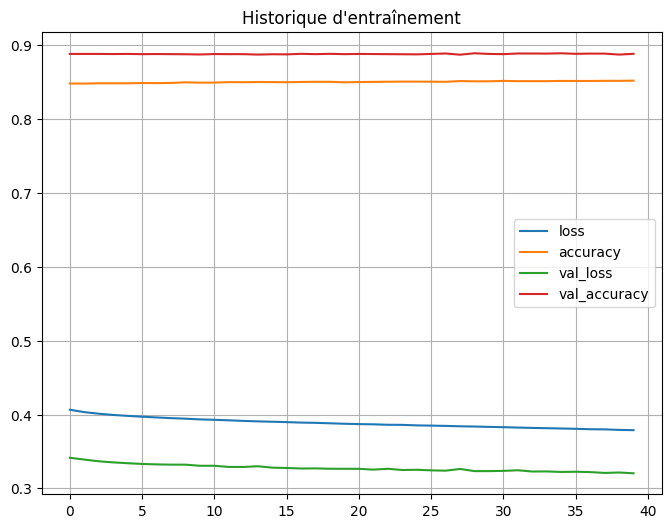

In [20]:
pd.DataFrame(result.history).plot(figsize=(8,6))
plt.title("Historique d'entraînement")
plt.grid(True)
plt.show()

In [21]:
print("Evaluation")
model.evaluate([x_test_profil, x_test_history], y_test)

Evaluation
500/500 [==============================] - 2s 4ms/step - loss: 0.8193 - accuracy: 0.6239


[0.8192632794380188, 0.623851478099823]

In [22]:
x_test_1, x_test_2 = x_test_profil[4:10], x_test_history[4:10]
print("Prédictions")
y_pred = model.predict([x_test_1, x_test_2])
print(f"y_pred = {np.argmax(y_pred,axis=1)}")
print(f"y_true = \n{y_test[4:10]}")

Prédictions
1/1 [==============================] - 0s 256ms/step
y_pred = [0 0 0 0 0 0]
y_true = 
34004    0
34005    0
34006    0
34007    1
34008    0
34009    0
Name: default.payment.next.month, dtype: int64
